In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import geemap
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('use_inf_as_na',True)

import datetime
import pwlf
import numpy as np
import xarray as xr
import rasterio
from pathlib import Path
from tqdm.notebook import tqdm

In [3]:
# Analysis Parameters
imageset = '../images/images_TurkeyHill1/'
modelset = '../data/TurkeyHill1.pkl'
#save_image = '../data/quality.png'
#save_csv = '../data/results_TurkeyHill1/quality.csv'

In [4]:
# get the filenames for all tif files
data_path = Path(imageset) 
file_list = np.array(sorted(list(data_path.glob('*.tif'))))

# an open list to store data array
da_list = []

for filename in file_list:
    # Sentinel-2
    date = filename.name.split('T')[0] # get rid of .tif
    date = date[0:4] + '-' + date[4:6] + '-' + date[6:8] # Put into ISO format
    
    # Landsat
    #date = filename.name.split('_')[2] # get rid of .tif
    #date = date[0:4] + '-' + date[4:6] + '-' + date[6:8] # Put into ISO format
    with rasterio.open(filename, 'r') as src:
        im = src.read()
        # read image into ndarray

        # transpose the matrix from (band, row, col) to (row, col, band)
        im = np.transpose(im, [1,2,0])

        # set null values
        im[im == 0.] = np.nan

        # get coordinates
        # first axis, from north to south
        lat_array = np.linspace(src.bounds[3],src.bounds[1],im.shape[0])
        # second axis, from west to east
        lon_array = np.linspace(src.bounds[0],src.bounds[2],im.shape[1])

        src.close()
        
        da = xr.Dataset({'EVI':(('lat','lon'),im[:,:,0]), 'NIRv':(('lat','lon'),im[:,:,1])},
                        coords={'lat':lat_array,'lon':lon_array})
        
        # add time dimension
        da = da.expand_dims('time')
        da.coords['time'] = [np.datetime64(date)]
        
        # append the data array to da_list
        
        da_list.append(da)

In [5]:
all_data = xr.merge(da_list)

In [6]:
all_data

<xarray.Dataset>
Dimensions:  (lat: 113, lon: 85, time: 322)
Coordinates:
  * lat      (lat) float64 4.702e+06 4.702e+06 4.702e+06 ... 4.7e+06 4.7e+06
  * lon      (lon) float64 3.832e+05 3.832e+05 3.832e+05 ... 3.841e+05 3.841e+05
  * time     (time) datetime64[ns] 2018-12-25 2018-12-27 ... 2022-12-29
Data variables:
    EVI      (time, lat, lon) float64 nan nan nan nan ... 0.1284 0.1361 nan nan
    NIRv     (time, lat, lon) float64 nan nan nan nan ... 0.07165 nan nan

### Define functions for extracting data from a pixel and fitting seasonal trend

In [7]:
# Extract day of year and year information from system index
def add_doy_year(df):
    safe_df = df.copy()
    
    safe_df['Year'] = safe_df['time'].map(lambda x: x.year)
    safe_df['doy'] = safe_df['time'].map(lambda x: x.timetuple().tm_yday)
    return safe_df

# Normalizes data within year
def normalize_VI(df, band):
    safe_df = df.copy()
    transformed = safe_df[['Year', band]]
    
    safe_df[f'{band}_nrml'] = transformed.groupby(['Year']).transform(lambda x: (x - x.min())/(x.max() - x.min()))[band]
    return safe_df
    
# Removes outliers using a window method
def remove_outliers(df, column):
    safe_df = df.copy()
    
    mean = safe_df[column].mean()
    std = safe_df[column].std()
    safe_df[f'{column}_z_score'] = (safe_df[column] - mean)/std
    
    mask = (safe_df[f'{column}_z_score'] <= 1) & (safe_df[f'{column}_z_score'] >= -1)
    return safe_df[mask]

def window_remove_outliers(df, column, window_column, window_size):
    n = (df[window_column].max() - df[window_column].min()) // window_size
    clean_df = pd.DataFrame()
    
    for i in range(n):
        win_start = i*window_size + df[window_column].min()
        if i == n - 1:
            win_end = df[window_column].max() + 1
        else:
            win_end = (i+1)*window_size + df[window_column].min()
        
        mask = (df[window_column] >= win_start) & (df[window_column] < win_end)
        # If window only has one element, keep it. Otherwise remove outliers
        if df[mask].size == 1:
            clean_df = pd.concat([clean_df,df[mask]])
        else:
            clean_df = pd.concat([clean_df,remove_outliers(df[mask], column)])
    
    return clean_df

# Duplicate df to have 2 'years' worth of data
def duplicate_doy(df):
    safe_df = df.copy()
    safe_df['doy'] += 365
    
    return pd.concat([df, safe_df])

# Normalize df
def normalize_doy(df, break_guesses):
    safe_df = df.copy()
    safe_df['doy_nrml'] = (safe_df['doy'] - safe_df['doy'].min()) / (safe_df['doy'].max()-safe_df['doy'].min())
    break_guesses = (break_guesses - safe_df['doy'].min()) / (safe_df['doy'].max()-safe_df['doy'].min())
    return safe_df, break_guesses

# Fits a piecewise linear regression to data  
def fit_pwlf(df, break_guesses):
    model = pwlf.PiecewiseLinFit(df['doy'], df['EVI_nrml'], seed=1358275)
    model.fit_guess(break_guesses)
    return model

# Calculate defoliation index from anomaly
def calc_defol(df):
    early_mask = (df['doy'] >= 120) & (df['doy'] <= 180) & (df['EVI_anom'] < 0)
    min_early = (df.loc[early_mask])['EVI_anom'].min()
    #mean_early = (df.loc[early_mask])['EVI_anom'].mean()
    
    late_mask = (df['doy'] >= 200) & (df['doy'] <= 250) & (df['EVI_anom'] < 0)
    min_late = (df.loc[late_mask])['EVI_anom'].min()
    #mean_late = (df.loc[late_mask])['EVI_anom'].mean()
    # Method 1:
    # return (min_late-.25)/min_early
    
    # Method 2:
    # return min_early*min_late + min_early*min_early
    
    # Method 3:
    return (np.abs(min_early) - np.abs(min_late))/(np.abs(min_early) + np.abs(min_late))
    
    # Method 4:
    # return ((np.abs(min_early) - np.abs(min_late))/(np.abs(min_early) + np.abs(min_late))) * (1 - np.abs(min_late))
    
    # Method 5:
    #return (np.abs(mean_early) - np.abs(mean_late))/(np.abs(mean_early) + np.abs(mean_late))

In [19]:
def process_point(dataset, latitude, longitude):
    # Paramters for analysis
    band = 'EVI'
    
    df = dataset.sel(lat=latitude, lon=longitude).to_pandas().reset_index().dropna()
    if len(df) == 0:
        return np.nan, np.nan, np.nan
    
    # Extract day of year and year information from system index
    df = add_doy_year(df)
    
    year_mask = df['Year'] >= 2019
    df = df.loc[year_mask]
    
    # Normalizes data within year
    df = normalize_VI(df, band)
    #df['EVI_nrml'] = df['EVI']
    
    # Removes outliers using a window method
    df = window_remove_outliers(df, band, 'doy', 15)
    
    #break_guesses = np.array()
    
    # Normalize doy
    #df, break_guesses = normalize_doy(df, break_guesses)
    
    # Duplicate df to have 2 'years' worth of data
    df = duplicate_doy(df)
    
    # Fits a piecewise linear regression to data
    model = fit_pwlf(df, [120, 150, 275, 310, 490, 540, 650])
    
    # Calculate anomaly
    df['EVI_pred'] = model.predict(df['doy'])
    df['EVI_anom'] = df['EVI_nrml'] - df['EVI_pred']
    
    # Record maximum anomaly for 2021
    mask = (df['Year'] == 2020)
    #return calc_defol(df.loc[mask])
    #(df.loc[mask])['EVI_anom'].min(),
    return (model.intercepts, model.slopes, model.fit_breaks)

In [20]:
defol = pd.DataFrame(columns = ['lat', 'lon', 'intercepts', 'slopes', 'breaks'])
x_index = all_data.get_index('lon')
y_index = all_data.get_index('lat')

with tqdm(total = len(x_index)*len(y_index)) as pbar:
    for y in y_index:
        for x in x_index:
            intercepts, slopes, breaks = process_point(all_data, y, x)
            defol.loc[len(defol.index)] = [y, x, intercepts, slopes, breaks]
            pbar.update(1)
            
defol.to_pickle(modelset)

  0%|          | 0/9605 [00:00<?, ?it/s]

C:\Users\camer\anaconda3\envs\gee\lib\site-packages\pandas\core\dtypes\cast.py:949: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  element = np.asarray(element)


In [18]:
defol.to_pickle(modelset)

In [11]:
defol = defol.dropna().copy()

In [12]:
def quality_check(breaks):
    # Returns 1 if breaks appear to appropriately placed 0 otherwise
    breaks_in_season = sum([br < 400 for br in breaks])
    if breaks_in_season == 5:
        return 1
    else:
        return 0

defol['quality'] = defol['breaks'].map(quality_check)

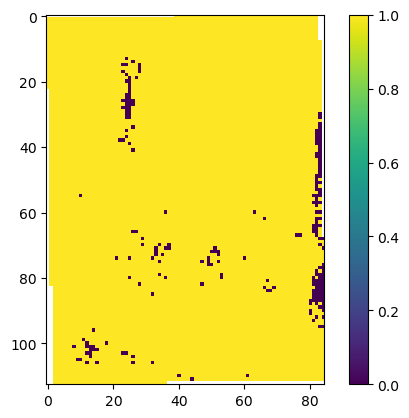

In [13]:
defol_pivot = defol[['lat','lon','quality']].pivot(index = 'lat', columns = 'lon')
plt.imshow(defol_pivot)
plt.colorbar()

In [14]:
def break_count(breaks):
    # Returns 1 if breaks appear to appropriately placed 0 otherwise
    return sum([br < 400 for br in breaks])

defol['break_count'] = defol['breaks'].map(break_count)

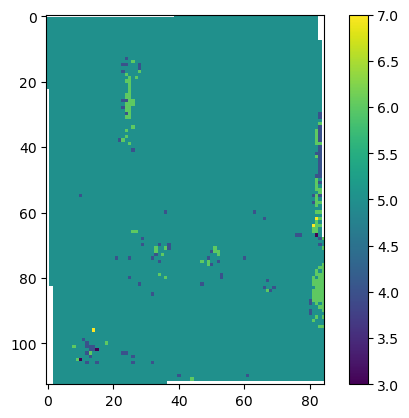

In [15]:
defol_pivot = defol[['lat','lon','break_count']].pivot(index = 'lat', columns = 'lon')
plt.imshow(defol_pivot)
plt.colorbar()

In [16]:
mask = defol['break_count'] == 2
defol[mask]

,lat,lon,intercepts,slopes,breaks,quality,break_count


In [17]:
def model_predict(intercepts, slopes, breaks, value):
    if value < breaks[0]:
        return slopes[0]*value + intercepts[0]
    for i in range(len(breaks)-1):
        if breaks[i] <= value and value < breaks[i+1]:
            return slopes[i]*(value) + intercepts[i]
    return slopes[-1]*value + intercepts[-1]

X_grid = np.linspace(0, 365*2, 1000)
y_grid = [model_predict(defol.loc[mask,'intercepts'].iloc[0],defol.loc[mask,'slopes'].iloc[0],defol.loc[mask,'breaks'].iloc[0],x) for x in X_grid]

IndexError: single positional indexer is out-of-bounds

In [ ]:
band = 'EVI'
    
df = all_data.isel(lat=2, lon=91).to_pandas().reset_index().dropna()
    
# Extract day of year and year information from system index
df = add_doy_year(df)
    
year_mask = df['Year'] >= 2019
df = df.loc[year_mask]
    
# Normalizes data within year
df = normalize_VI(df, band)
    
# Removes outliers using a window method
df = window_remove_outliers(df, band, 'doy', 15)
    
#break_guesses = np.array()
    
# Normalize doy
#df, break_guesses = normalize_doy(df, break_guesses)
    
# Duplicate df to have 2 'years' worth of data
df = duplicate_doy(df)

In [ ]:
plt.plot(X_grid,y_grid)
plt.plot(df['doy'], df['EVI_nrml'], 'o')